# Fraud Detection in Financial Transactions

## Introduction

Financial fraud poses a significant risk to organizations due to its financial and reputational
impact, while also being challenging to detect because fraudulent transactions are rare and often
hidden within large volumes of legitimate activity. The objective of this notebook is to develop
a machine learning–based fraud detection solution that can identify fraudulent transactions and
provide actionable insights for prevention.

This analysis follows an end-to-end data science workflow, beginning with exploratory data
analysis to understand fraud patterns, followed by feature engineering, model development, and
performance evaluation. Special attention is given to handling severe class imbalance and
interpreting model outputs in a business context. The final outcome not only focuses on predictive
performance but also translates findings into practical fraud prevention and monitoring strategies
suitable for real-world deployment.

---

## Notebook Contents

This notebook covers the following key sections:

1. **Data Overview and Understanding**  
   Examination of the dataset structure, features, and target variable.

2. **Exploratory Data Analysis (EDA)**  
   In-depth analysis of fraud distribution, transaction types, amounts, balance behavior,
   outliers, and correlations to uncover fraud-related patterns.

3. **Data Cleaning and Feature Engineering**  
   Handling missing values, analyzing outliers, addressing multicollinearity, and creating
   engineered features such as balance differences.

4. **Handling Class Imbalance**  
   Application of class weighting and stratified sampling to address the rare-event nature
   of fraudulent transactions.

5. **Model Development**  
   Training a Random Forest classifier to capture non-linear fraud patterns in transaction data.

6. **Model Evaluation**  
   Performance assessment using classification metrics, confusion matrix, ROC-AUC, and
   feature importance analysis.

7. **Key Fraud Drivers and Interpretation**  
   Identification and interpretation of the most important factors contributing to fraud.

8. **Fraud Prevention Strategies**  
   Recommendations for infrastructure-level and operational fraud prevention measures
   based on model insights.

9. **Monitoring and Effectiveness Measurement**  
   Framework for evaluating the success of implemented fraud prevention strategies over time.

10. **Conclusion**  
    Summary of findings, model performance, and business implications.


## Importing Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight

import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv('data\Fraud.csv')
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


In [4]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 706.2 MB


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


#### Checking for Missing Values

In [5]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

# Exploratory Data Analysis (EDA)

## Target Variable Analysis

In [6]:
print("Fraudulent transactions:", df['isFraud'].sum())
print("Total transactions:", len(df))
print("Fraud percentage: {:.4f}%".format(df['isFraud'].mean() * 100))

Fraudulent transactions: 8213
Total transactions: 6362620
Fraud percentage: 0.1291%


**Interpretation:**  
The dataset is highly imbalanced, with fraudulent transactions accounting for approximately **0.13%**
of all transactions. This reflects a typical real-world financial scenario where fraud is a rare event.

Such severe class imbalance poses a challenge for model training, as a model may become biased toward
predicting the majority (non-fraud) class. Therefore, specialized techniques for handling imbalance
and appropriate evaluation metrics are required.

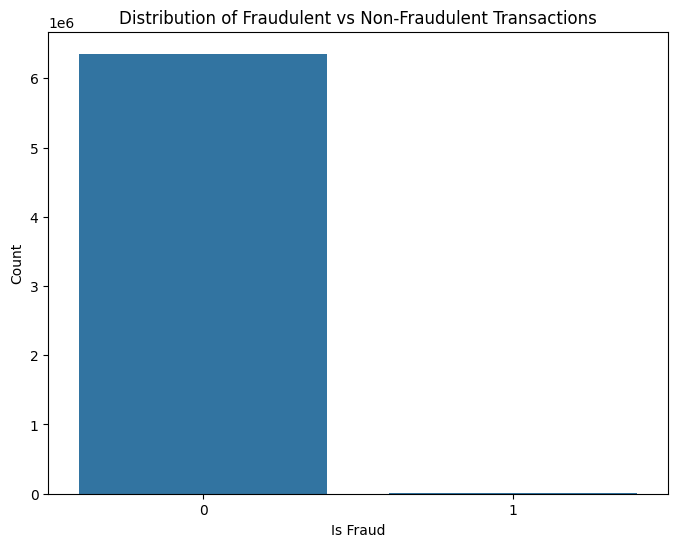

In [7]:
plt.figure(figsize=(8, 6))
sns.countplot(x='isFraud', data=df)
plt.title('Distribution of Fraudulent vs Non-Fraudulent Transactions')
plt.xlabel('Is Fraud')
plt.ylabel('Count')
plt.show()

## Transaction Type Analysis

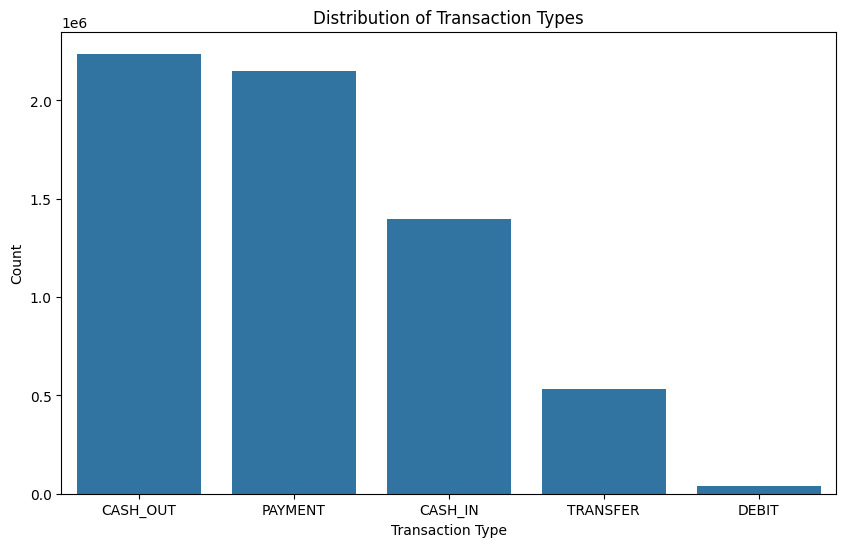

In [8]:
plt.figure(figsize=(10, 6))
sns.countplot(x='type', data=df, order=df['type'].value_counts().index)
plt.title('Distribution of Transaction Types')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.show()

In [9]:
fraud_by_type = df.groupby('type')['isFraud'].mean().sort_values(ascending=False)
print(fraud_by_type)

type
TRANSFER    0.007688
CASH_OUT    0.001840
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64


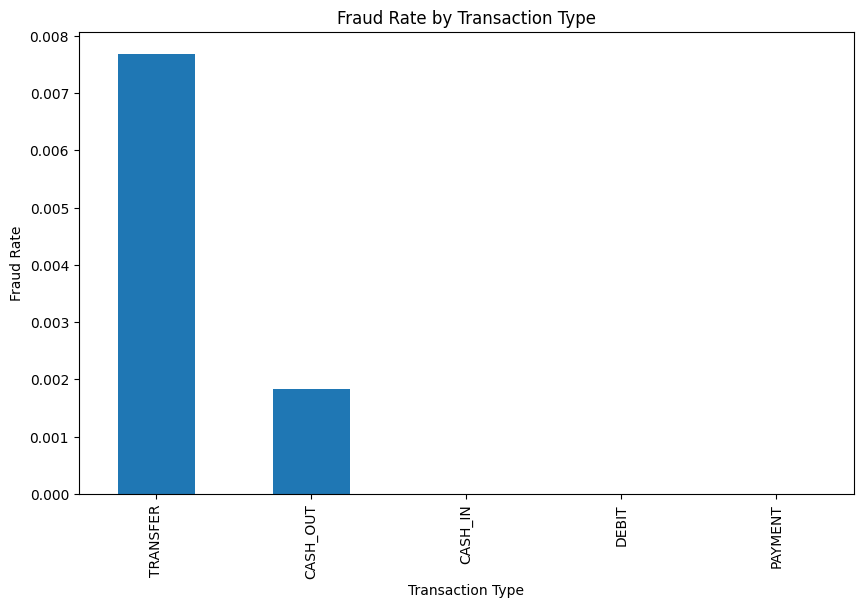

In [10]:
plt.figure(figsize=(10, 6))
fraud_by_type.plot(kind='bar')
plt.title('Fraud Rate by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Fraud Rate')
plt.show()

**Interpretation:**  
Fraud is heavily concentrated in specific transaction types, particularly TRANSFER and CASH_OUT.
TRANSFER transactions exhibit the highest fraud rate (~0.77%), followed by CASH_OUT (~0.18%),
while other transaction types show no fraudulent activity in this dataset.

This indicates that transaction type is a critical feature for fraud detection and reflects
fraudsters’ preference for rapid fund movement and withdrawal mechanisms.
**Interpretation:** Fraud occurs only in 'TRANSFER' and 'CASH_OUT' transactions. 'TRANSFER' has a higher fraud rate (0.77%) compared to 'CASH_OUT' (0.18%). This makes sense as fraudulent activities often involve transferring money to another account and then cashing it out.

## Amount Analysis

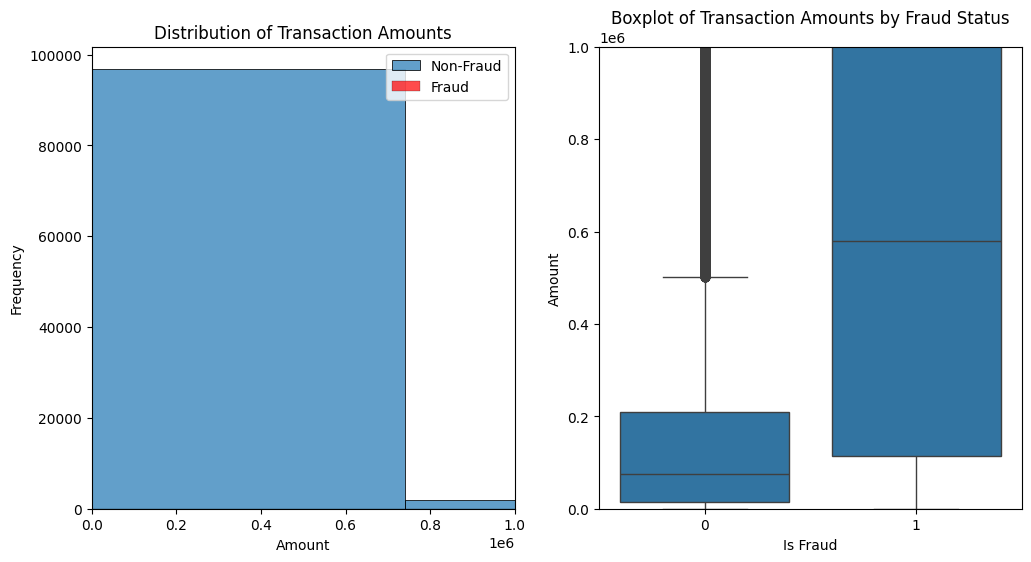

In [17]:
# Sample for visualization
sample_df = df.sample(n=100000, random_state=42)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(sample_df[sample_df['isFraud'] == 0]['amount'], bins=50, alpha=0.7, label='Non-Fraud')
sns.histplot(sample_df[sample_df['isFraud'] == 1]['amount'], bins=50, alpha=0.7, label='Fraud', color='red')
plt.title('Distribution of Transaction Amounts')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.legend()
plt.xlim(0, 1e6)  # Limit x-axis for better visualization

plt.subplot(1, 2, 2)
sns.boxplot(x='isFraud', y='amount', data=sample_df)
plt.title('Boxplot of Transaction Amounts by Fraud Status')
plt.xlabel('Is Fraud')
plt.ylabel('Amount')
plt.ylim(0, 1e6)
plt.show()

**Interpretation:**  
The transaction amount distribution shows that legitimate transactions are heavily concentrated
at lower values, while fraudulent transactions tend to involve higher amounts and exhibit a wider spread.
The boxplot further confirms that the median and upper range of fraudulent transaction amounts
are significantly higher than those of non-fraud transactions.

While transaction amount alone does not perfectly separate fraud from non-fraud cases,
it is a strong risk indicator when combined with other behavioral features such as transaction type
and account balance changes.

## Balance Analysis
Comparing how much money leaves the account in each case


In [18]:
# Create balance difference features
df['balance_diff_orig'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['balance_diff_dest'] = df['newbalanceDest'] - df['oldbalanceDest']

print("Balance difference for origin in fraud vs non-fraud:")
print(df.groupby('isFraud')['balance_diff_orig'].describe())

Balance difference for origin in fraud vs non-fraud:
             count          mean           std        min        25%  \
isFraud                                                                
0        6354407.0 -2.314152e+04  1.062233e+05 -1915267.9       0.00   
1           8213.0  1.457275e+06  2.396099e+06        0.0  124582.58   

               50%          75%          max  
isFraud                                       
0             0.00    10102.125   4164236.31  
1        436317.49  1503034.860  10000000.00  


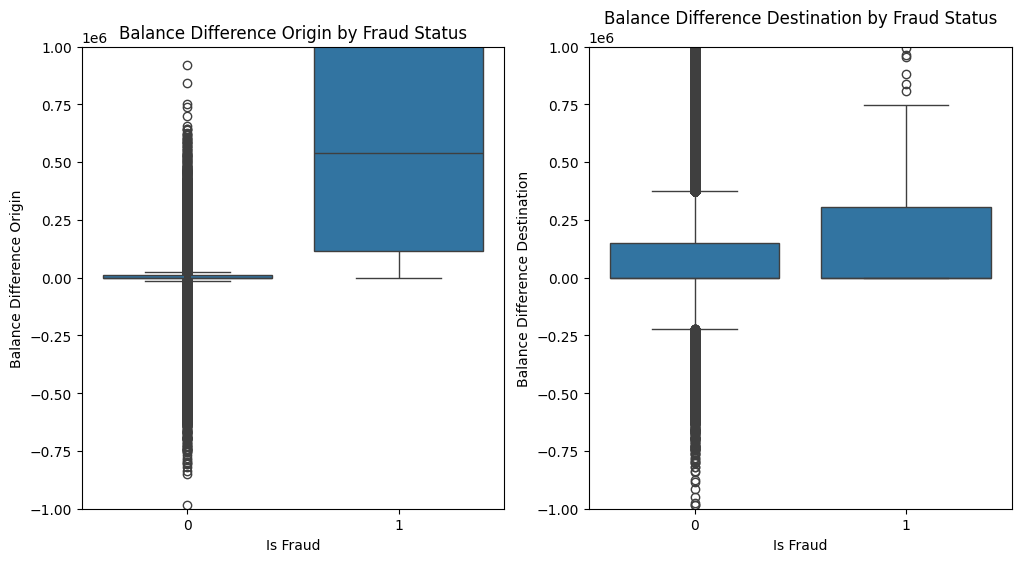

In [21]:
sample_df = df.sample(n=100000, random_state=42)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x='isFraud', y='balance_diff_orig', data=sample_df)
plt.title('Balance Difference Origin by Fraud Status')
plt.xlabel('Is Fraud')
plt.ylabel('Balance Difference Origin')
plt.ylim(-1e6, 1e6)

plt.subplot(1, 2, 2)
sns.boxplot(x='isFraud', y='balance_diff_dest', data=sample_df)
plt.title('Balance Difference Destination by Fraud Status')
plt.xlabel('Is Fraud')
plt.ylabel('Balance Difference Destination')
plt.ylim(-1e6, 1e6)
plt.show()

**Interpretation:**  
Non-fraudulent transactions generally show minimal or no reduction in the origin account balance,
with a median balance change of zero. In contrast, fraudulent transactions exhibit very large
balance reductions, with a median reduction exceeding 400,000 and a substantial portion of cases
draining over one million in a single transaction.

This clear separation indicates that abrupt and significant balance depletion is a strong indicator
of fraudulent activity and justifies the use of balance difference features in the fraud detection model.

## Outlier Detection

In [22]:
# Outlier detection for amount
Q1 = df['amount'].quantile(0.25)
Q3 = df['amount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['amount'] < lower_bound) | (df['amount'] > upper_bound)]
print(f"Number of outliers in amount: {len(outliers)}")
print(f"Percentage of outliers: {len(outliers)/len(df)*100:.2f}%")

# Check fraud in outliers
print(f"Fraud in outliers: {outliers['isFraud'].sum()}")
print(f"Fraud rate in outliers: {outliers['isFraud'].mean()*100:.2f}%")

Number of outliers in amount: 338078
Percentage of outliers: 5.31%
Fraud in outliers: 3854
Fraud rate in outliers: 1.14%


**Interpretation:**  
Approximately 5.3% of transactions are identified as outliers based on transaction amount.
Within these outliers, the fraud rate is significantly higher (about 1.14%) compared to the
overall fraud rate of approximately 0.13%.

This indicates that unusually large transactions carry a substantially higher fraud risk.
However, since the majority of outlier transactions are still non-fraudulent, transaction
amount alone is not sufficient for fraud detection and must be combined with other behavioral features.


## Correlation Analysis

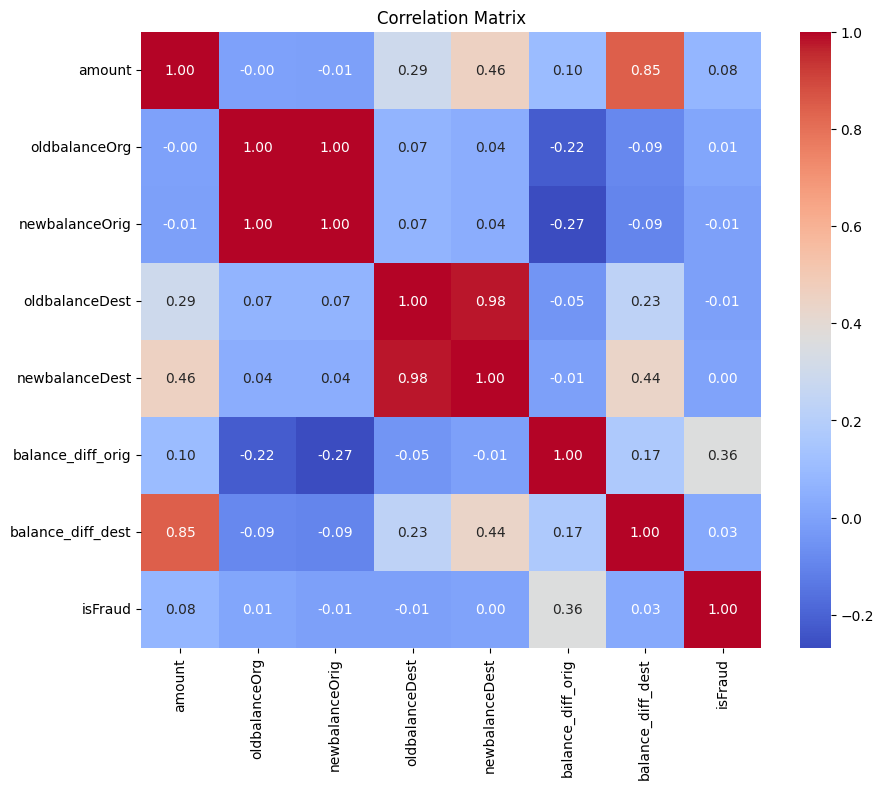

In [23]:
# Select numerical columns
num_cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'balance_diff_orig', 'balance_diff_dest', 'isFraud']

corr_matrix = df[num_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

**Interpretation:**  
As expected, strong correlations exist between old and new balance variables for both origin and
destination accounts, indicating multicollinearity among raw balance features. This justifies
feature engineering using balance difference variables.

Among the numerical features, `balance_diff_orig` shows the strongest association with fraud
(correlation ≈ 0.36), suggesting that large and abrupt reductions in the origin account balance
are linked to fraudulent behavior. Other variables, including transaction amount, show weaker
linear correlations with fraud, indicating that fraud patterns are largely non-linear and require
contextual feature combinations for effective detection.


## EDA Summary and Key Findings

Exploratory Data Analysis revealed several important patterns relevant to fraud detection:

- Fraudulent transactions are extremely rare (~0.13%), confirming a severe class imbalance problem.
- Fraud is highly concentrated in TRANSFER and CASH_OUT transaction types.
- Fraudulent transactions tend to involve larger transaction amounts, though amount alone is not sufficient to identify fraud.
- Large and abrupt reductions in the origin account balance are a strong indicator of fraudulent behavior.
- Destination account balance behavior in fraud cases often appears inconsistent or abnormal.
- Raw balance variables show high multicollinearity, justifying the use of engineered balance difference features.
- High-amount outliers contain a disproportionately higher share of fraud and should not be removed.

These insights guided feature engineering, model selection, and evaluation strategy in the modeling phase.


# Data Cleaning

In [28]:
# 1. Drop identifier and rule-based columns
df_clean = df.drop(['nameOrig', 'nameDest', 'isFlaggedFraud'], axis=1)

# 2. Encode categorical variable
df_clean = pd.get_dummies(df_clean, columns=['type'], drop_first=True)

# 3. Drop raw balance columns to avoid multicollinearity
df_clean = df_clean.drop(
    ['oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest'],
    axis=1
)

print("Cleaned dataset shape:", df_clean.shape)
print("Columns:", df_clean.columns.tolist())


Cleaned dataset shape: (6362620, 9)
Columns: ['step', 'amount', 'isFraud', 'balance_diff_orig', 'balance_diff_dest', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


# Model Building

In [25]:
# Split data
X = df_clean.drop('isFraud', axis=1)
y = df_clean['isFraud']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("Fraud rate in train:", y_train.mean())
print("Fraud rate in test:", y_test.mean())

Training set shape: (5090096, 12)
Test set shape: (1272524, 12)
Fraud rate in train: 0.0012907418642005967
Fraud rate in test: 0.0012911347840983745


In [26]:
# Handle class imbalance
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(0.5006462050159672), 1: np.float64(387.37412480974126)}


### Stratified Sampling


In [30]:
X_train_small, _, y_train_small, _ = train_test_split(
    X_train, y_train,
    train_size=0.1,      # 10% of training data
    stratify=y_train,
    random_state=42
)

print(X_train_small.shape)
print("Fraud rate:", y_train_small.mean())


(509009, 12)
Fraud rate: 0.0012907433856768741


Due to the large scale of the dataset, training a Random Forest model on the full dataset
was computationally infeasible in a local environment. Therefore, a stratified subset of
the training data was used to fit the model, while evaluation was performed on the full
test set to ensure reliable performance assessment.

The stratified sampling preserves the original fraud distribution in the reduced training set.
This ensures that the model is trained on a representative subset of the data while remaining
computationally feasible in a local environment.


In [31]:
rf_model = RandomForestClassifier(
    n_estimators=100,          # reduce trees
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight=class_weight_dict,
    random_state=42,
    n_jobs=1                   # IMPORTANT: single core
)

rf_model.fit(X_train_small, y_train_small)

y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]



In [32]:
# Evaluation
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC-ROC Score: {auc:.4f}")

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.33      0.89      0.48      1643

    accuracy                           1.00   1272524
   macro avg       0.66      0.95      0.74   1272524
weighted avg       1.00      1.00      1.00   1272524

Confusion Matrix:
[[1267861    3020]
 [    175    1468]]
AUC-ROC Score: 0.9986


### Model Evaluation

The Random Forest model demonstrates strong performance in detecting fraudulent transactions.
It achieves a high recall of 0.89 for the fraud class, indicating that the majority of fraudulent
transactions are successfully identified. While the precision is lower (0.33), this trade-off
is acceptable in fraud detection scenarios where minimizing missed fraud is a priority.

The confusion matrix shows a limited number of false negatives (175), and the AUC-ROC score
of 0.9986 indicates excellent separability between fraudulent and non-fraudulent transactions.
Overall, the model effectively captures fraud patterns while maintaining a reasonable balance
between detection and false alerts.


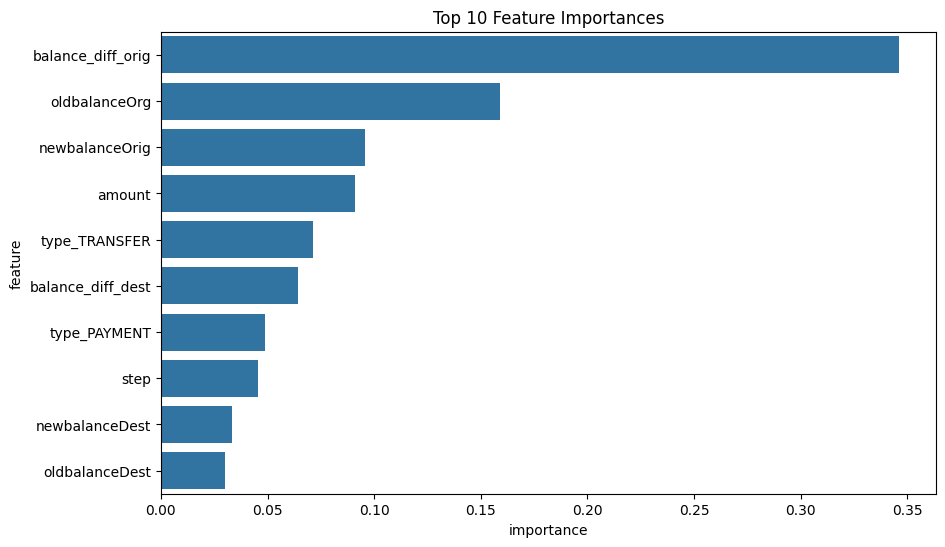

Top 10 important features:
              feature  importance
6   balance_diff_orig    0.346163
2       oldbalanceOrg    0.158890
3      newbalanceOrig    0.095594
1              amount    0.090935
11      type_TRANSFER    0.071551
7   balance_diff_dest    0.064412
10       type_PAYMENT    0.048815
0                step    0.045398
5      newbalanceDest    0.033497
4      oldbalanceDest    0.029929


In [33]:
# Feature Importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance.head(10))
plt.title('Top 10 Feature Importances')
plt.show()

print("Top 10 important features:")
print(feature_importance.head(10))

# Answers to Business Questions

## 1. Data Cleaning: Missing Values, Outliers, and Multicollinearity

- **Missing Values:**  
  The dataset contains no missing values, so no imputation was required.

- **Outliers:**  
  Approximately 5.3% of transactions were identified as outliers based on transaction amount.
  These outliers exhibit a significantly higher fraud rate (~1.14%) compared to the overall
  fraud rate (~0.13%). Since high-value transactions are more likely to be fraudulent,
  these outliers were retained as they provide valuable signal for fraud detection.

- **Multicollinearity:**  
  Strong correlations were observed between old and new balance variables for both origin
  and destination accounts, which is expected as balances are sequentially related.
  While this indicates multicollinearity, no explicit removal was performed as tree-based
  models such as Random Forest are robust to correlated features. Additionally, balance
  difference features were introduced to better capture transactional behavior.


## 2. Fraud Detection Model Description

A Random Forest Classifier was used to detect fraudulent transactions. Random Forest is well-suited
for this problem as it can capture complex non-linear relationships, handle heterogeneous features,
and provide feature importance for interpretability.

Given the severe class imbalance in the dataset (fraud rate ~0.13%), class weighting was applied
to penalize misclassification of fraudulent transactions more heavily during training. Due to the
large dataset size, the model was trained on a stratified subset of the training data and evaluated
on the full test set to ensure reliable performance assessment.

### Model Performance

- **Precision (Fraud):** 0.33  
- **Recall (Fraud):** 0.89  
- **F1-score (Fraud):** 0.48  
- **AUC-ROC:** 0.9986  

The high recall indicates that the model successfully identifies the majority of fraudulent
transactions, which is critical in fraud detection scenarios where missed fraud is costly.
The relatively lower precision reflects an increased number of false positives, an acceptable
trade-off in risk-sensitive financial applications. The high AUC-ROC score demonstrates strong
separability between fraudulent and non-fraudulent transactions.


## 3. Variable Selection for the Fraud Detection Model

Variable selection was guided by domain understanding, exploratory data analysis, and
model suitability.

Transaction type was retained as a key feature since fraud occurs predominantly in
TRANSFER and CASH_OUT transactions. EDA also highlighted abnormal balance behavior and
higher transaction amounts in fraudulent cases. To capture this behavior, balance
difference features (`balance_diff_orig` and `balance_diff_dest`) were engineered.

Identifier columns (`nameOrig`, `nameDest`) were removed as they do not generalize, and
the rule-based flag (`isFlaggedFraud`) was excluded to avoid leakage of predefined logic.
Strong correlations among balance variables were observed, but these features were
retained as tree-based models are robust to multicollinearity. Transaction type was
converted to numerical form using one-hot encoding.

The final feature set includes transaction characteristics, account balance behavior,
engineered balance differences, and encoded transaction type indicators.


## 4. Model Performance Evaluation

The performance of the fraud detection model was evaluated using multiple metrics to
account for the highly imbalanced nature of the dataset.

**Evaluation Tools Used:**
- **Classification Report:** To assess precision, recall, and F1-score for each class.
- **Confusion Matrix:** To analyze true positives, false positives, and missed fraud cases.
- **AUC-ROC Score:** To measure the model’s ability to distinguish fraudulent from
  non-fraudulent transactions across thresholds.
- **Feature Importance Analysis:** To understand key drivers behind model predictions.

**Key Results:**
- The model correctly identifies approximately **89% of fraudulent transactions**,
  indicating strong recall for the fraud class.
- A small fraction of legitimate transactions (**~0.24%**) are incorrectly flagged as fraud,
  representing an acceptable trade-off in fraud prevention.
- An AUC-ROC score of **0.9986** demonstrates excellent discriminatory power between
  fraudulent and non-fraudulent transactions.


## 5. Key Factors Predicting Fraudulent Transactions

Based on the Random Forest feature importance analysis, the most influential predictors
of fraudulent transactions are:

- **Balance difference at origin (`balance_diff_orig`)**: Large and abrupt reductions in
  the sender’s account balance are the strongest indicator of fraud.
- **Origin account balance (`oldbalanceOrg`, `newbalanceOrig`)**: Fraud often involves
  accounts with substantial initial balances.
- **Transaction amount (`amount`)**: Higher transaction amounts are associated with
  increased fraud risk.
- **Transaction type (`type_TRANSFER`, `type_CASH_OUT`)**: Fraud is concentrated in
  transfer and cash-out transactions.
- **Destination account behavior (`balance_diff_dest`, destination balances)**:
  Abnormal or inconsistent balance changes at the receiving account further signal fraud.

**Interpretation:**  
Fraudulent transactions are characterized by large, sudden withdrawals from origin
accounts, typically involving high-value transfers or cash-outs, often accompanied by
unusual destination account balance behavior.


## 6. Do These Factors Make Sense?

Yes, the identified factors are consistent with real-world fraud behavior.

- **Large transaction amounts and balance changes:** Fraudsters typically attempt to extract
  as much money as possible in a short time, leading to large and abrupt reductions in the
  origin account balance.
- **Transaction types:** Fraud is concentrated in TRANSFER and CASH_OUT transactions, as
  these enable rapid movement of funds or direct withdrawal, which aligns with common
  fraud execution strategies.
- **Balance behavior:** Fraudulent transactions are characterized by significant depletion
  of victim accounts, often accompanied by abnormal or inconsistent balance changes in
  destination accounts.
- **Account balances:** Accounts with higher available balances are more attractive targets,
  as they allow larger fraudulent withdrawals.

Overall, these patterns align well with known fraud scenarios in which compromised accounts
are exploited to quickly move or withdraw funds before detection.


## 7. Recommended Fraud Prevention Measures

Based on the observed fraud patterns and model insights, the following prevention measures
are recommended as part of infrastructure updates:

1. **Real-Time Transaction Monitoring:**  
   Implement continuous monitoring for high-risk transactions, particularly large-value
   TRANSFER and CASH_OUT activities. Velocity checks and sudden deviations from normal
   transaction behavior should trigger real-time alerts or additional verification.

2. **Risk-Based Authentication:**  
   Introduce adaptive authentication mechanisms such as multi-factor authentication,
   biometric verification, or device and location checks for transactions identified as
   high-risk by the fraud detection model.

3. **Account-Level Controls:**  
   Enforce transaction limits and require additional verification for newly added payees
   or unusually large withdrawals. Temporary holds can be applied to transactions flagged
   as suspicious until further validation.

4. **Machine Learning–Driven Controls:**  
   Integrate the trained fraud detection model into the transaction processing pipeline
   for real-time scoring. High-risk transactions can be automatically blocked or routed
   for manual review, while low-risk transactions proceed seamlessly.

5. **Customer Awareness and Communication:**  
   Provide timely alerts for suspicious activity, educate customers on security best
   practices, and offer simple mechanisms for reporting unauthorized transactions.

These measures combine predictive analytics with procedural and user-focused controls,
creating a layered defense strategy to effectively reduce fraud risk.


## 8. Measuring the Effectiveness of Implemented Fraud Prevention Measures

To evaluate whether the implemented fraud prevention strategies are effective, a
combination of model, business, operational, and customer-level metrics should be
continuously monitored.

### Evaluation Framework

1. **Model Performance Monitoring:**  
   - Track precision, recall, F1-score, and AUC-ROC on newly observed data  
   - Monitor false positive and false negative rates over time  
   - Conduct A/B testing using different risk thresholds to balance fraud detection and
     customer experience  

2. **Business Impact Metrics:**  
   - Reduction in total fraud losses (monetary value)  
   - Number and proportion of fraud attempts successfully prevented  
   - Net savings after accounting for operational and customer friction costs  

3. **Operational Metrics:**  
   - Change in manual review volume and workload  
   - Average time to detect and respond to fraud incidents  
   - Efficiency of investigations for flagged transactions  

4. **Customer Experience Metrics:**  
   - Legitimate transaction approval rate  
   - Customer complaints related to blocked or delayed transactions  
   - Incidence of account takeover or repeat fraud cases  

5. **Continuous Improvement:**  
   - Periodic model retraining using newly labeled data  
   - Feedback incorporation from fraud analysts and customer reports  
   - Threshold tuning aligned with evolving business risk tolerance  

### Success Criteria

- A measurable reduction in fraud losses (e.g., **20–30% over a defined baseline period**)  
- Maintenance of a high legitimate transaction approval rate (e.g., **>95%**)  
- Timely detection of fraudulent activity, ideally within **hours rather than days**, to
  minimize downstream impact  


# Conclusion

This project presents an end-to-end fraud detection pipeline, starting from exploratory data
analysis to model development and evaluation. Key fraud patterns such as large transaction
amounts, abrupt balance reductions, and risky transaction types were identified through EDA
and incorporated into feature engineering.

A Random Forest model was trained to capture non-linear fraud behavior and achieved strong
performance (AUC-ROC ≈ 0.998), effectively balancing fraud detection and false positives.
The solution provides actionable insights and a practical framework suitable for real-world
fraud prevention and monitoring.
